

# Experiments with Mistral as a Juge on fine-tuned reports

## Loading Mistral 7b and the data

In [1]:
# Clone the repo (skip if already cloned)
!git clone https://github.com/JeremieTarantop/Cardiac-Diagnostic-CMR-report-.git repo_cmr
%cd repo_cmr

Cloning into 'repo_cmr'...
remote: Enumerating objects: 15965, done.
remote: Counting objects: 100% (15965/15965), done.
remote: Compressing objects: 100% (15115/15115), done.
remote: Total 15965 (delta 1206), reused 15037 (delta 311), pack-reused 0 (from 0)
Receiving objects: 100% (15965/15965), 34.46 MiB | 13.24 MiB/s, done.
Resolving deltas: 100% (1206/1206), done.
/content/repo_cmr


In [8]:
from pathlib import Path

ROOT = Path(".")
MEETI_TXT_ROOT = ROOT / "data" / "20260209_MEETI TXT"
MEETI_TXT_DIR = ROOT / "data" / "20260209_MEETI TXT"
FINE_TUNED_DIR = MEETI_TXT_ROOT / "generated_reports_fine_tuned_v1" / "hallucinated_fine_tuned_first100"

PROMPT_PATH = ROOT / "prompt_v1.txt"
assert PROMPT_PATH.exists(), f"Missing: {PROMPT_PATH}"
assert MEETI_TXT_DIR.exists(), f"Missing: {MEETI_TXT_DIR}"
assert FINE_TUNED_DIR.exists(), f"Missing: {FINE_TUNED_DIR}"

BASE_PROMPT = PROMPT_PATH.read_text(encoding="utf-8").strip()

OUT_DIR = ROOT / "data" / "outputs_dpo_mistral" / "artifacts_1_2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)
print("PROMPT_PATH:", PROMPT_PATH)
print("MEETI_TXT_DIR:", MEETI_TXT_DIR)
print("OUT_DIR:", OUT_DIR)


Root: .
PROMPT_PATH: prompt_v1.txt
MEETI_TXT_DIR: data/20260209_MEETI TXT
OUT_DIR: data/outputs_dpo_mistral/artifacts_1_2


In [3]:
import json

def safe_read_text(path: Path) -> str | None:
    try:
        return path.read_text(encoding="utf-8").strip()
    except UnicodeDecodeError:
        try:
            return path.read_text(encoding="latin-1").strip()
        except Exception:
            return None
    except Exception:
        return None

def collect_meeti_records(meeti_root: Path, limit: int = 500):
    report_files = sorted(meeti_root.rglob("*_report.txt"))
    records = []
    skipped = 0

    for rf in report_files:
        rec_id = rf.name.replace("_report.txt", "")
        interp_f = rf.parent / f"{rec_id}_llm_interpretation.txt"

        short_report = safe_read_text(rf)
        llm_interp = safe_read_text(interp_f) if interp_f.exists() else None

        if not short_report or not llm_interp:
            skipped += 1
            continue

        records.append({
            "id": rec_id,
            "short_report": short_report,
            "llm_interpretation": llm_interp,
            "folder": str(rf.parent),
            "report_path": str(rf),
            "interpretation_path": str(interp_f),
        })

        if len(records) >= limit:
            break

    return records, {"found_report_files": len(report_files), "loaded": len(records), "skipped": skipped}

records, stats = collect_meeti_records(MEETI_TXT_ROOT, limit=100)
stats




{'found_report_files': 806, 'loaded': 100, 'skipped': 306}

In [4]:
!pip -q install -U transformers accelerate bitsandbytes sentencepiece

# Ensures we have:
# Latest transformers, Latest accelerate, Quantization support, Tokenizer backend
# Without version mismatches.

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.3"

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 4-bit config (recommended on Colab)
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# Model (generator)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",
    quantization_config=bnb_cfg,
    torch_dtype=torch.float16,
)
model.eval()
# Switches model to evaluation mode (disables dropout and training-specific behavior)
# Ensures stable, deterministic inference during generation

print("Loaded:", MODEL_ID)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 164.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.0 MB/s eta 0:00:00


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loaded: mistralai/Mistral-7B-Instruct-v0.3


### Loading the reports



In [9]:
from pathlib import Path

ROOT = Path(".")
MEETI_TXT_ROOT = ROOT / "data" / "20260209_MEETI TXT"
GEN_DIR = ROOT / "data" / "20260209_MEETI TXT" / "generated_reports"

assert MEETI_TXT_ROOT.exists(), f"Missing: {MEETI_TXT_ROOT}"
assert GEN_DIR.exists(), f"Missing: {GEN_DIR}"


def find_llm_interpretation_by_id(meeti_root: Path, rec_id: str) -> Path | None:
    """
    Search MEETI tree for the matching {rec_id}_llm_interpretation.txt
    Example target: .../p1000/p10000032/s40689238/{rec_id}_llm_interpretation.txt
    """
    matches = list(meeti_root.rglob(f"{rec_id}_llm_interpretation.txt"))
    if not matches:
        return None
    # Prefer the shortest path (usually the most direct match) to avoid duplicates if any
    matches.sort(key=lambda p: len(str(p)))
    return matches[0]



In [10]:
import re

def extract_response_only(text: str) -> str:
    """
    Extracts text after the SECOND occurrence of 'Response:' or '**Response:**'.
    This avoids keeping prompt scaffolding when the prompt itself contains 'Response:'.
    """

    if not text:
        return ""

    # Find all occurrences of markdown or plain Response:
    pattern = r"\*\*Response:\*\*|\bResponse:"
    matches = list(re.finditer(pattern, text))

    if len(matches) >= 2:
        # Cut after the second occurrence
        second = matches[1]
        return text[second.end():].strip()

    elif len(matches) == 1:
        # Fallback: only one found
        return text[matches[0].end():].strip()

    # If none found, return original
    return text.strip()

In [15]:
# Loading pairs of reports

def load_first_200_pairs(meeti_root: Path, gen_dir: Path):
    """
    Returns list of dicts:
      {id, generated_report, llm_interpretation, gen_path, llm_path}
    for the first 10 generated reports that have a matching llm_interpretation file.
    """
    gen_files = sorted(gen_dir.glob("*.txt"))  # generated reports are txt
    pairs = []
    skipped = 0

    for gf in gen_files:
        rec_id = gf.stem.split("_")[0]  # handles: {id}_hallucinated.txt or {id}_mistral_hallucination.txt
        raw_gen_text = safe_read_text(gf)
        if not raw_gen_text:
            skipped += 1
            continue

        gen_text = extract_response_only(raw_gen_text)

        ft_path = FINE_TUNED_DIR / f"{rec_id}_hallucinated_fine_tuned.txt"
        if ft_path is None:
            skipped += 1
            continue

        ft_text_raw = safe_read_text(ft_path)
        if not ft_text_raw:
            skipped += 1
            continue

        pairs.append({
            "id": rec_id,
            "generated_report": gen_text,
            "ft_report": ft_text_raw,
            "gen_path": str(gf),
            "ft_path": str(ft_path),
        })

        if len(pairs) >= 200:
            break

    return pairs, {"generated_files_found": len(gen_files), "paired": len(pairs), "skipped": skipped}

pairs200, stats200 = load_first_200_pairs(MEETI_TXT_ROOT, GEN_DIR)

print(stats200)
print([p["id"] for p in pairs200])

# Example: show the first pair paths (sanity check)
if pairs200:
    print("First pair:")
    print("ID:", pairs200[0]["id"])
    print("Generated path:", pairs200[0]["gen_path"])
    print("Fine-tuned report path:", pairs200[0]["ft_path"])

{'generated_files_found': 100, 'paired': 100, 'skipped': 0}
['40056908', '40067704', '40341634', '40539087', '40689238', '40695233', '40742173', '40746075', '40761639', '40816324', '40894787', '40925049', '41103859', '41309390', '41316269', '41366957', '41420867', '41445586', '41557927', '41798696', '41800350', '41997536', '42060926', '42178586', '42186899', '42315368', '42368611', '42413061', '42546971', '42695383', '42709053', '42742896', '42790963', '42855628', '42947358', '43013697', '43143228', '43468501', '43492795', '43522917', '43576724', '43647002', '43681375', '43742645', '43744967', '43749278', '44069449', '44095784', '44458630', '44669583', '44837313', '44881309', '44986768', '45090959', '45105401', '45386375', '45594411', '45808859', '45832921', '45842645', '45896667', '45986118', '46034277', '46049322', '46293961', '46440135', '46543372', '46566322', '46642833', '46743816', '46857734', '47004256', '47218930', '47226536', '47286409', '47499371', '47544594', '47843381', '47

In [16]:
# Visualization of the inputs of the judge

if pairs200:
    p = pairs200[1]

    print("="*80)
    print("PATIENT ID:", p["id"])
    print("="*80)

    print("\n--- GENERATED REPORT ---\n")
    print(p["generated_report"])

    print("\n" + "="*80)
    print("\n--- GENERATED REPORT WITH FINE TUNING ---\n")
    print(p["ft_report"])

PATIENT ID: 40067704

--- GENERATED REPORT ---

Upon thorough examination of the provided ECG data, several key features and potential abnormalities have been identified.

In Lead I, the ST segment exhibits a notable elevation, which, when combined with the characteristic rsR pattern in Lead V1, suggests the presence of right ventricular hypertrophy (RVH) or right bundle branch block (RBBB). Additionally, the PR interval in Lead II indicates a possible conduction delay, potentially pointing towards atrial enlargement.

Moving to Lead II, the ST segment and T wave changes indicate an inferior wall ischemia or infarction, supporting the hypothesis of RVH or RBBB, as these conditions often involve right ventricular ischemia.

In Leads III and aVF, the presence of Q waves and ST segment and T wave changes is consistent with inferior infarction or ischemia, further supporting the diagnosis of RVH or RBBB.

The ST segment elevation in Lead aVL and the T wave inversion in Lead aVR suggest hig

## Best working prompt

In [23]:
# This prompt is doing well (79/100) on a sample of 100 reports

import json
import re
import torch
from pathlib import Path
from datetime import datetime

JUDGE_SYSTEM = "You are a strict cardiac MRI (CMR) report JUDGE. Follow instructions exactly."

JUDGE_INSTRUCTIONS = """
You will compare two reports about the same case.

Select the report that is superior based on:

1) Clinical realism
2) Logical consistency
3) Absence of hallucination
4) Appropriate level of detail
5) No instructional or template artifacts

Hallucination includes:
- Invented findings
- Overly specific diagnoses without support
- Generic templated reasoning not grounded in the report


Do NOT reward verbosity.
Do NOT reward confidence.
Reward realism and grounded reasoning.

If REPORT B is better according to the criteria, output winner="B", good_report="B", bad_report="A".
If REPORT A is better according to the criteria, output winner="A", good_report="A", bad_report="B".

Output ONLY valid JSON:
{
  "winner": "...",
  "good_report": "...",
  "bad_report": "..."
}
""".strip()

def _extract_last_json_object(text: str) -> str:
    """
    Extract the last JSON object from a text blob.
    This avoids grabbing an earlier schema example or echoed prompt.
    """
    matches = re.findall(r"\{[\s\S]*?\}", text)
    if not matches:
        raise ValueError(f"No JSON object found. Raw output:\n{text}")

    cand = matches[-1].strip()

    cand = re.sub(r",\s*}", "}", cand)
    cand = re.sub(r",\s*]", "]", cand)
    cand = re.sub(r"\bNone\b", "null", cand)
    cand = re.sub(r"\bTrue\b", "true", cand)
    cand = re.sub(r"\bFalse\b", "false", cand)

    return cand

@torch.inference_mode()
def mistral_judge_pair(report_a: str, report_b: str, max_new_tokens: int = 120) -> dict:
    user_prompt = (
        JUDGE_INSTRUCTIONS
        + "\n\nREPORT A:\n" + report_a.strip()
        + "\n\nREPORT B:\n" + report_b.strip()
        + "\n\nReturn JSON now."
    )

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": user_prompt},
    ]
    chat = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(chat, return_tensors="pt").to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    text = decoded[len(chat):].strip() if decoded.startswith(chat) else decoded.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    cand = _extract_last_json_object(text)
    try:
        return json.loads(cand)
    except json.JSONDecodeError as e:
        raise ValueError(
            "Model output was not valid JSON.\n\n"
            f"--- Last JSON candidate ---\n{cand}\n\n"
            f"--- Raw model output ---\n{text}\n"
        ) from e


N_PAIRS_TO_JUDGE = 100  # change this to 10, 50, 100, etc.
MAX_NEW_TOKENS = 300

# If you want the output file name to reflect N:
JUDGE_OUT = Path("data") / f"judge_results_{N_PAIRS_TO_JUDGE}.jsonl"
JUDGE_OUT.parent.mkdir(parents=True, exist_ok=True)

# Choose only the first N pairs
pairs_to_judge = pairs200[:N_PAIRS_TO_JUDGE]

results = []
total = len(pairs_to_judge)

for i, p in enumerate(pairs_to_judge, start=1):
    rec_id = p["id"]

    report_a = p["ft_report"]   # A = Fine tuned report
    report_b = p["generated_report"]     # B = generated

    judgment = mistral_judge_pair(report_a, report_b, max_new_tokens=MAX_NEW_TOKENS)

    row = {
        "id": rec_id,
        "report_A_type": "ft_report",
        "report_B_type": "generated_hallucination",
        "report_A_path": p["ft_path"],
        "report_B_path": p["gen_path"],
        "judgment": judgment,
    }
    results.append(row)

    print(f"[{i}/{total}] {rec_id} winner={judgment.get('winner')}")

with open(JUDGE_OUT, "w", encoding="utf-8") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print("Saved:", JUDGE_OUT)

[1/100] 40056908 winner=A
[2/100] 40067704 winner=A
[3/100] 40341634 winner=B
[4/100] 40539087 winner=B
[5/100] 40689238 winner=B
[6/100] 40695233 winner=B
[7/100] 40742173 winner=B
[8/100] 40746075 winner=A
[9/100] 40761639 winner=A
[10/100] 40816324 winner=B
[11/100] 40894787 winner=A
[12/100] 40925049 winner=B
[13/100] 41103859 winner=A
[14/100] 41309390 winner=A
[15/100] 41316269 winner=A
[16/100] 41366957 winner=B
[17/100] 41420867 winner=A
[18/100] 41445586 winner=A
[19/100] 41557927 winner=A
[20/100] 41798696 winner=B
[21/100] 41800350 winner=A
[22/100] 41997536 winner=B
[23/100] 42060926 winner=B
[24/100] 42178586 winner=B
[25/100] 42186899 winner=B
[26/100] 42315368 winner=B
[27/100] 42368611 winner=A
[28/100] 42413061 winner=A
[29/100] 42546971 winner=A
[30/100] 42695383 winner=A
[31/100] 42709053 winner=B
[32/100] 42742896 winner=B
[33/100] 42790963 winner=A
[34/100] 42855628 winner=B
[35/100] 42947358 winner=A
[36/100] 43013697 winner=B
[37/100] 43143228 winner=A
[38/100] 4

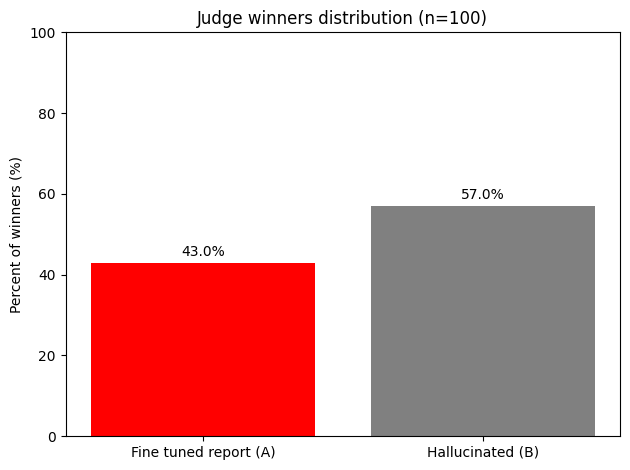

In [24]:
import json
import matplotlib.pyplot as plt

# Works for 10, 100, 500... just point to the right JSONL
JUDGE_OUT = Path("data") / "judge_results_100.jsonl"
assert JUDGE_OUT.exists(), f"Missing: {JUDGE_OUT}"

wins_A = 0  # A = Fine tuned report
wins_B = 0  # B = generated hallucination
n = 0

with open(JUDGE_OUT, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        winner = obj.get("judgment", {}).get("winner")
        if winner == "A":
            wins_A += 1
            n += 1
        elif winner == "B":
            wins_B += 1
            n += 1
        else:
            # ignore malformed rows
            pass

assert n > 0, "No valid judged rows found."

pct_llm = 100.0 * wins_A / n
pct_halluc = 100.0 * wins_B / n

labels = ["Fine tuned report (A)", "Hallucinated (B)"]
values = [pct_llm, pct_halluc]
colors = ["red", "grey"]

plt.figure()
plt.bar(labels, values, color=colors)
plt.ylim(0, 100)
plt.ylabel("Percent of winners (%)")
plt.title(f"Judge winners distribution (n={n})")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


### Creating nice graph

In [27]:
import matplotlib.pyplot as plt

def plot_manual_judge_distribution(pct_B: float,
                                    n: int = 100,
                                    label_A: str = "Fine-tuned (A)",
                                    label_B: str = "Baseline (B)"):
    """
    Create a judge-style bar plot using a manually provided percentage for B.

    pct_B: percentage of B wins (0–100)
    n: total number of samples (used only for title display)
    """

    assert 0 <= pct_B <= 100, "pct_B must be between 0 and 100"

    pct_A = 100.0 - pct_B

    labels = [label_A, label_B]
    values = [pct_A, pct_B]
    colors = ["red", "grey"]

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=colors)

    plt.ylim(0, 100)
    plt.ylabel("Percent of winners (%)")
    plt.title(f"Judge winners distribution with baseline vs fine-tuned reports (n={n})")

    for bar, v in zip(bars, values):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()
        plt.text(x, y - 10, f"{v:.1f}%", ha="center", va="center")

    plt.tight_layout()
    plt.show()

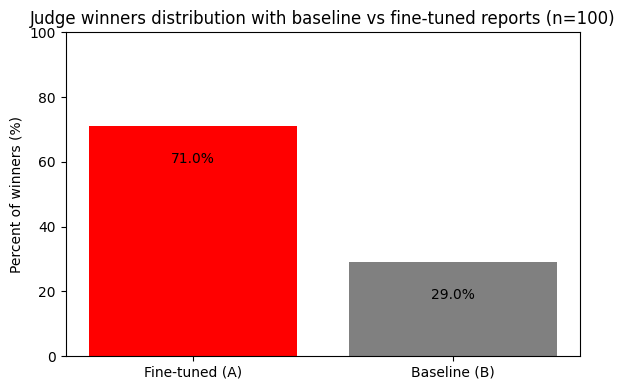

In [29]:
plot_manual_judge_distribution(pct_B=29, n=100)